<a href="https://colab.research.google.com/github/ibtihal7alharbi-tech/ML-project/blob/main/Ml_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
# إذا طلع لك اسم الملف مختلف، عدله هنا بعد ما تشوف نتيجة ls
df = pd.read_csv("/content/sleep_health_dataset.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [4]:
# نظرة عامة سريعة
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicated rows:", df.duplicated().sum())

Columns:
['person_id', 'age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']

Data types:


,0
person_id,int64
age,int64
gender,object
occupation,object
bmi,float64
country,object
sleep_duration_hrs,float64
sleep_quality_score,float64
rem_percentage,float64
deep_sleep_percentage,float64



Missing values:


,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0



Duplicated rows: 0


In [6]:
# تقسيم الأعمدة
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Numeric columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numeric columns: ['person_id', 'age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']

Categorical columns: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']


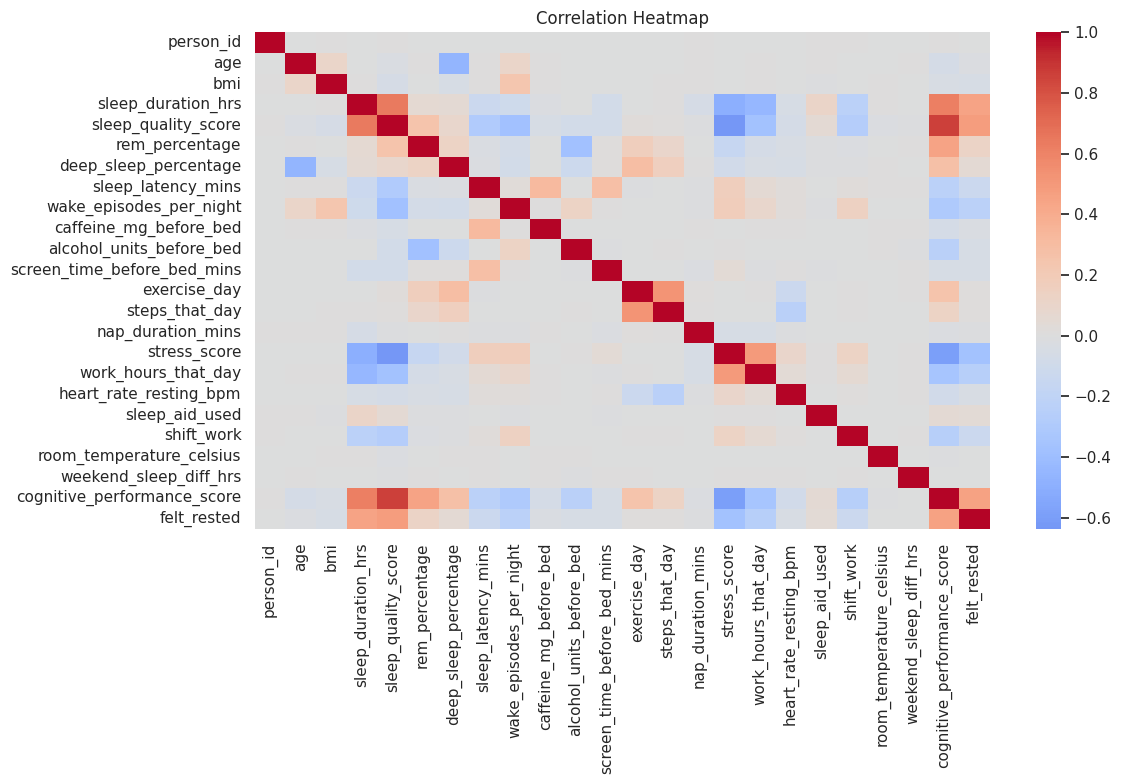

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
corr_target = df.corr(numeric_only=True)["cognitive_performance_score"].sort_values(ascending=False)
print(corr_target)

cognitive_performance_score    1.000000
sleep_quality_score            0.859978
sleep_duration_hrs             0.618241
felt_rested                    0.451526
rem_percentage                 0.445967
deep_sleep_percentage          0.280368
exercise_day                   0.254680
steps_that_day                 0.135033
sleep_aid_used                 0.046867
person_id                      0.001601
weekend_sleep_diff_hrs        -0.003075
room_temperature_celsius      -0.009311
nap_duration_mins             -0.020294
bmi                           -0.037134
screen_time_before_bed_mins   -0.044216
caffeine_mg_before_bed        -0.065320
age                           -0.067792
heart_rate_resting_bpm        -0.090691
sleep_latency_mins            -0.225244
alcohol_units_before_bed      -0.240015
shift_work                    -0.254351
wake_episodes_per_night       -0.294673
work_hours_that_day           -0.345869
stress_score                  -0.592584
Name: cognitive_performance_score, dtype

In [9]:
corr_target = df.corr(numeric_only=True)["felt_rested"].sort_values(ascending=False)
print(corr_target)

felt_rested                    1.000000
sleep_quality_score            0.478843
cognitive_performance_score    0.451526
sleep_duration_hrs             0.443114
rem_percentage                 0.119252
deep_sleep_percentage          0.051823
sleep_aid_used                 0.042328
exercise_day                   0.009143
steps_that_day                 0.008043
person_id                     -0.000301
room_temperature_celsius      -0.001677
weekend_sleep_diff_hrs        -0.002923
nap_duration_mins             -0.015957
age                           -0.019091
caffeine_mg_before_bed        -0.025494
heart_rate_resting_bpm        -0.041099
alcohol_units_before_bed      -0.044429
screen_time_before_bed_mins   -0.045657
bmi                           -0.047608
sleep_latency_mins            -0.127440
shift_work                    -0.129592
wake_episodes_per_night       -0.226104
work_hours_that_day           -0.251302
stress_score                  -0.365557
Name: felt_rested, dtype: float64


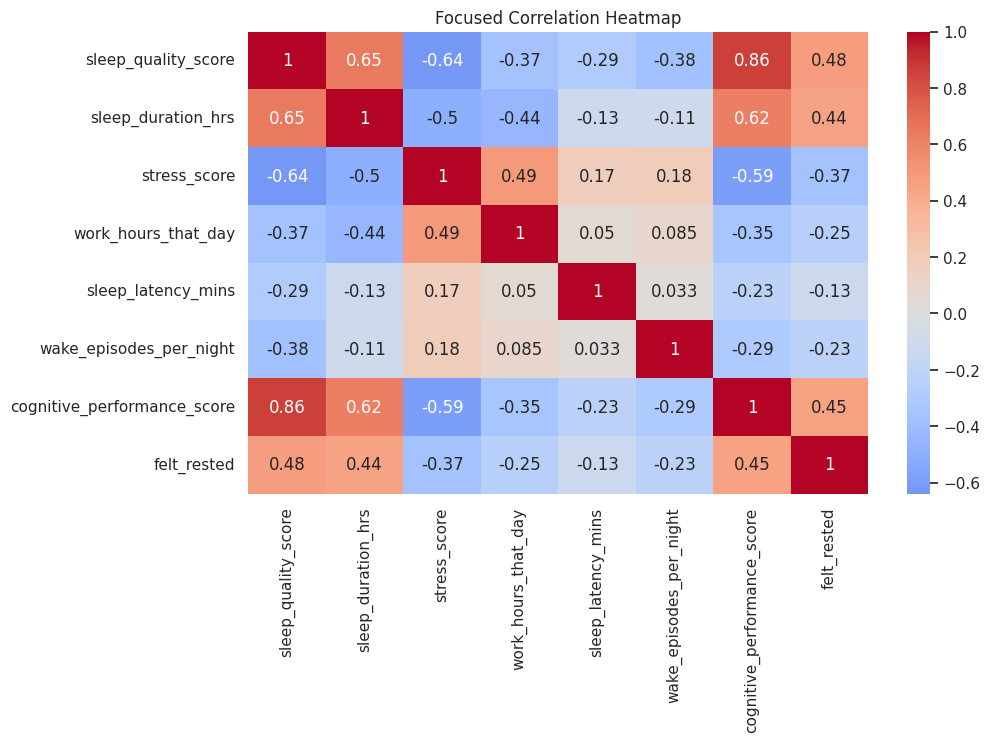

In [10]:
top_cols = ["sleep_quality_score", "sleep_duration_hrs", "stress_score",
            "work_hours_that_day", "sleep_latency_mins", "wake_episodes_per_night",
            "cognitive_performance_score", "felt_rested"]

plt.figure(figsize=(10,6))
sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Focused Correlation Heatmap")
plt.show()